# MNIST
## 05. Data quality and difficulties

In [1]:
from infdsa_mnist import mnist_load, mnist_output, data_quality, data_quality_output

(train_data, test_data) = mnist_load.load_mnist()
x_train, y_train = train_data
x_test, y_test = test_data

include_train = True
include_test = True

x_data, y_data = mnist_load.combine_data(x_train, y_train, x_test, y_test, include_train, include_test)

Before we can get started with training a model, we must understand the imperfections and challenges that may arise when working with the MNIST dataset. Even though the MNIST dataset is considered a "clean" dataset, it still contains imperfections and edge cases that can make classification of handwritten digits more challenging than it may initially seem. To understand these challenges, we will explore the dataset to answer the following question: **How do flaws and ambiguities in human handwriting affect the accuracy of machine learning models?**

To answer this question, more visual analysis of the dataset is required to identify specific examples of imperfections and ambiguities in the handwritten digits and to understand how these can affect the performance of machine learning models. To structure our analysis, we will break down the main question into several sub-questions that will guide our exploration of the dataset and help us identify what we need to be aware of when working with the MNIST dataset. The sub-questions we will address in this notebook are as follows:
1. How legible are the handwritten digits in the MNIST dataset?
2. What digit classes are the most challenging for computers to understand and why?

In this chapter, the data inserted into the functions will be processed as 1D arrays, meaning that the images will be flattened and the spatial relationships between pixels will not be taken into account. This is because the functions we will be using are designed to work with 1D arrays. This is a common limitation in simple machine learning models, and this will limit the accuracy of the results we will be getting. However, this will still allow us to identify some of the most important imperfections and challenges in the dataset and to understand how they can affect the performance of machine learning models when working with the MNIST dataset.

## How legible are the handwritten digits in the MNIST dataset?
To explore the legibility of the handwritten digits in the MNIST dataset, we can use the `find_ambiguous_digits` function from the `data_quality` module. This function uses a basic neural network to identify some of the most ambiguous digits in the dataset, alongside their confidence scores for the first and second guesses.

Calculating ambiguous digits (this may take a minute)...


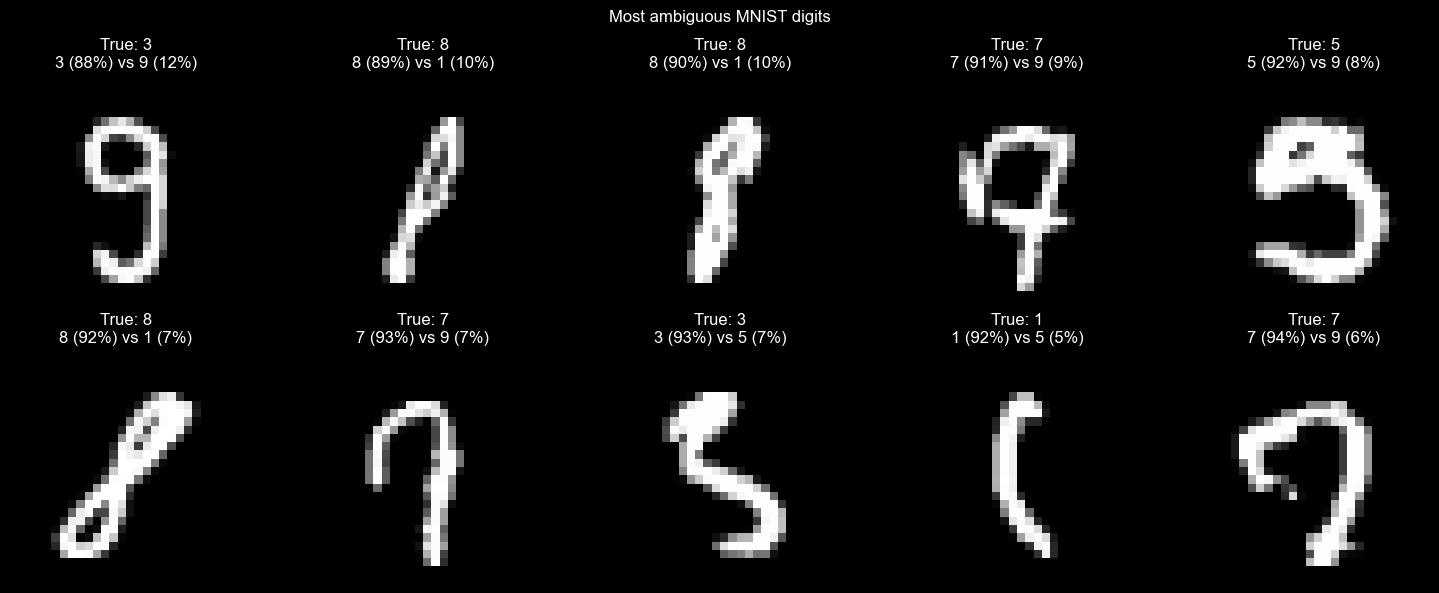

In [2]:
ambiguous_x, ambiguous_y = data_quality.find_ambiguous_digits(x_data, y_data, top_n=10, seed=42)

mnist_output.display_grid(ambiguous_x, ambiguous_y, rows=2, cols=5, title="Most ambiguous MNIST digits")

What we can gather from the displayed images is that there are indeed some digits in the dataset that take some time for humans to recognize, and that can easily be misclassified by a machine learning model. These digits can be considered edge cases, and they illustrate the imperfections and ambiguities that can arise in human handwriting.

To break this down, we can observe that the legibility of handwritten digits can be affected by various factors, such as:
- The thickness of the strokes
- How closely the strokes are connected (making 8's look like 1's, 5's look like 9's, etc.)
- The overall shape of the digit (e.g., a '2' that looks more like a '7')

Interestingly, the first digit in the displayed images looks exactly like a '9,' but both the label and the model's first guess indicate it's a '3.' This is the only digit in the displayed images that is labeled as a different digit than what humans would likely perceive it as, and it serves as a perfect example of how human errors in labeling can also contribute to the challenges of classifying handwritten digits, as supervised machine learning models rely heavily on the quality of the labels in the training data. If there are mislabeled examples in the dataset, it can lead to confusion for the model and ultimately affect its accuracy when classifying new unseen digits. We would like to warn that there may be more mislabeled examples in the dataset, and that the displayed images are just a sample of the most ambiguous digits. There may be other examples of mislabeled digits that we have not yet identified.

## What digit classes are the most challenging for computers to understand and why?
To explore the most challenging digit classes in the MNIST dataset, we can use the `get_error_matrix` function from the `data_quality` module. We will then visualize the results using the `display_error_heatmap` and `display_total_errors_barplot` functions from the `data_quality_output` module. The heatmap will show the absolute number of misclassifications for each pair of true and predicted digit classes. The chart will show the total number of errors per digit class. These visualizations will help us identify which digit classes are the most challenging for computers to understand. Based on the displayed heatmap and chart, we can make observations on why certain digit classes may be more challenging to classify than others, and what specific visual features may contribute to these challenges.

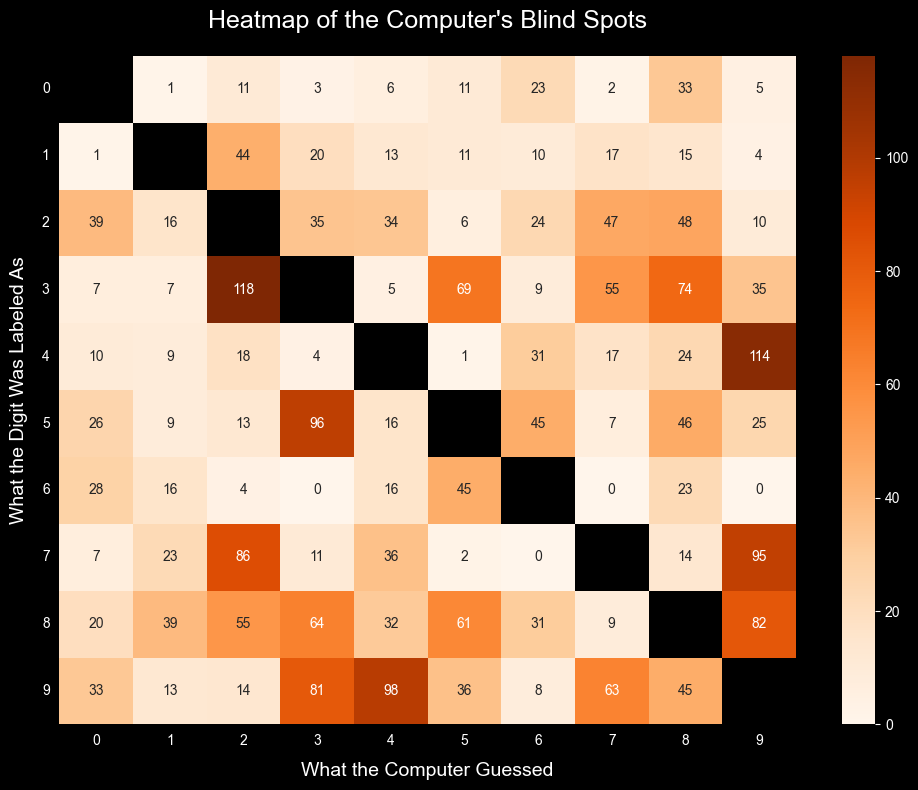

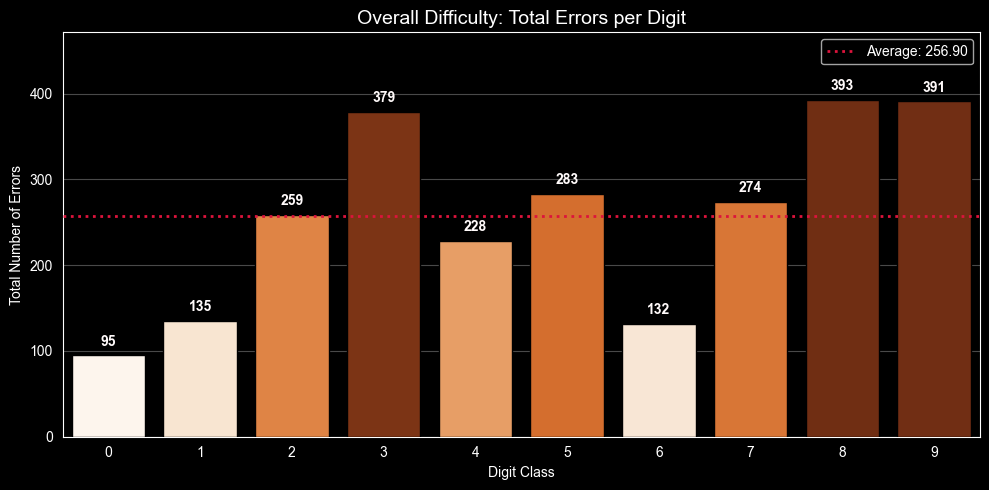

In [3]:
error_matrix = data_quality.get_error_matrix(x_data, y_data)

data_quality_output.display_error_heatmap(error_matrix, title="Heatmap of the Computer's Blind Spots")
data_quality_output.display_total_errors_barplot(error_matrix, title="Overall Difficulty: Total Errors per Digit")

As we can see from the displayed heatmap, certain digit classes are more challenging for computers to understand than others. The heatmap shows the absolute number of misclassifications for each pair of true and predicted digit classes. A '3' is most commonly misclassified as a '2,', but is also often confused with '5' and '8,' and sometimes with '7' and '9.' This is likely because '3' can look vastly different, depending on handwriting and sloppiness. What we can tell from the bar plot is that, despite having the highest number of misclassifications as a single other digit, '3' is not the most challenging digit class overall. That title goes to '8,' quickly followed by '9.' This is likely because '8' and '9' are both more consistently misclassified across multiple other digit classes.

What we can gather from this analysis is that certain digit classes, such as '8' and '9,' may be more challenging for computers to understand. This could be due to their visual similarities with other digit classes and the variability in how they can be written. Some specific features that contribute to these challenges include:
- The overall shape of the digit (e.g.: a '1' with a longer top, making it look like a '2')
- The sloppiness of the handwriting (e.g.: a '9' with an unclosed loop, making it look like a '4')
- The thickness of the strokes (e.g.: an '8' with thicker strokes, making it look like a '1' if the '8' is written narrowly)
- The presence of extra lines by accident (e.g.: a '7' with an extra line in the top left, making a loop that makes it look like a '9')
- How closely the strokes are connected (e.g.: a '4' that comes close to closing the top, making it look like a '9')

## Conclusion
After visually and mathematically exploring the edge cases of the dataset, we can now answer the main question posed in the introduction:
**How do flaws and ambiguities in human handwriting affect the accuracy of machine learning models?**

Flaws and ambiguities in handwriting can significantly affect the accuracy of machine learning models. Since a model learns strictly from the data it is provided, human error and messy handwriting directly translate into uncertainty in the model's predictions.

There are two main types of flaws and ambiguities that we have discovered:
- Human-made flaws (Data): Though MNIST is a standardized dataset, it still contains digits that are harder to recognize than others. Some labels are even incorrect, such as a '9' being labeled as a '3.' This means that if a training set contains contradictions, like telling the model that a '9' is a '3,' the model's accuracy will take a hit.
- Algorithm-made flaws (Model): By processing the images as flattened 1D arrays, simple models lose all understanding of 2D spatial relationships. Thus, they rely purely on the raw data to make decisions. We can see that some of these flaws can be easily overcome by using the 2D arrays directly, though that will require more complex models.


Because we now understand these inherent flaws in both the dataset and our initial 1D models, it is clear that simply feeding raw pixels into a basic algorithm will not yield perfect results. While 1D arrays are highly useful for the type of baseline mathematical analysis we just performed, they fall short when it comes to training a model to recognize handwritten digits.

Ultimately, recognizing limitations in the dataset and simple models is crucial in the machine learning process. By understanding these flaws and ambiguities, we can make informed decisions on how to best address them and model our approach specifically to overcome these challenges.

Before we can get started with trying out different ways to train a model, we must first understand how we can structure the data in a way that allows us to train a model more effectively. In the next chapter, therefore, we will explore different data structures that can be used to organize the MNIST dataset.